**Fraud Detection Model**

# 1. Imports & Setup

In [ ]:
!pip install imbalanced-learn -q
!pip install optuna -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, precision_recall_curve,
                             recall_score, precision_score, f1_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import optuna

warnings.filterwarnings('ignore')
logging.getLogger('lightgbm').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 500)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print('Libraries loaded successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.5 MB/s eta 0:00:00
Libraries loaded successfully!


# 2. Data Loading

In [ ]:
import pandas as pd

# Load Data Set
!pip install kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

# Load the data into a DataFrame
df = pd.read_csv('creditcard.csv')

# About dataset
df.shape

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 244MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


(284807, 31)

In [ ]:
print(f'Shape: {df.shape}')
print(f'Column types:\n{df.dtypes.value_counts()}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
df.head(5)


Shape: (284807, 31)
Column types:
float64    30
int64       1
Name: count, dtype: int64
Missing values: 0
Duplicate rows: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [ ]:
#print row with class =1
df[df['Class']==1].head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.000,-2.312,1.952,-1.610,3.998,-0.522,-1.427,-2.537,1.392,-2.770,-2.772,3.202,-2.900,-0.595,-4.289,0.390,-1.141,-2.830,-0.017,0.417,0.127,0.517,-0.035,-0.465,0.320,0.045,0.178,0.261,-0.143,0.000,1
623,472.000,-3.044,-3.157,1.088,2.289,1.360,-1.065,0.326,-0.068,-0.271,-0.839,-0.415,-0.503,0.677,-1.692,2.001,0.667,0.600,1.725,0.283,2.102,0.662,0.435,1.376,-0.294,0.280,-0.145,-0.253,0.036,529.000,1
4920,4462.000,-2.303,1.759,-0.360,2.330,-0.822,-0.076,0.562,-0.399,-0.238,-1.525,2.033,-6.560,0.023,-1.470,-0.699,-2.282,-4.782,-2.616,-1.334,-0.430,-0.294,-0.932,0.173,-0.087,-0.156,-0.543,0.040,-0.153,239.930,1
6108,6986.000,-4.398,1.358,-2.593,2.680,-1.128,-1.707,-3.496,-0.249,-0.248,-4.802,4.896,-10.913,0.184,-6.771,-0.007,-7.358,-12.598,-5.132,0.308,-0.172,0.574,0.177,-0.436,-0.054,0.252,-0.657,-0.827,0.850,59.000,1
6329,7519.000,1.234,3.020,-4.305,4.733,3.624,-1.358,1.713,-0.496,-1.283,-2.447,2.101,-4.610,1.464,-6.079,-0.339,2.582,6.739,3.042,-2.722,0.009,-0.379,-0.704,-0.657,-1.633,1.489,0.567,-0.010,0.147,1.000,1


# 3. Exploratory Data Analysis

3.1 Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64
Class
0   99.827
1    0.173
Name: proportion, dtype: float64


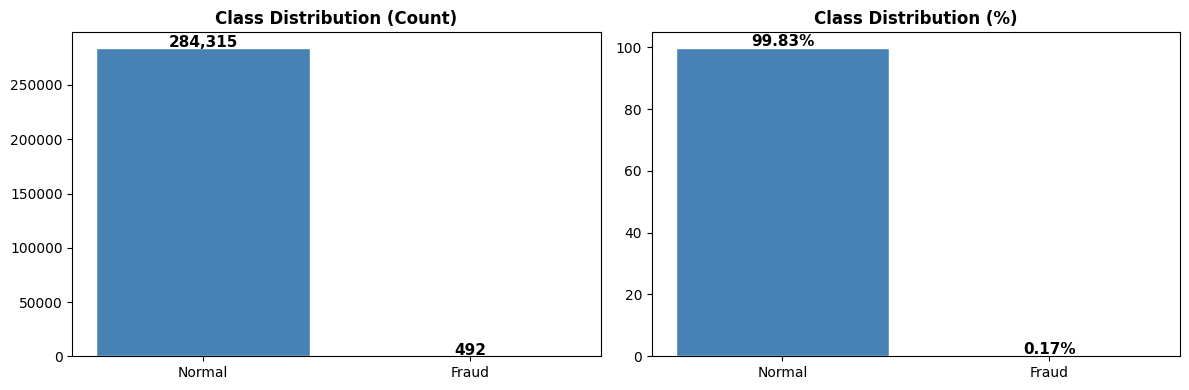

In [ ]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Class'].value_counts()
bars0 = axes[0].bar(['Normal', 'Fraud'], counts.values, color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
for bar, val in zip(bars0, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000,
                f'{val:,}', ha='center', fontsize=11, fontweight='bold')

pcts = df['Class'].value_counts(normalize=True).values * 100
bars1 = axes[1].bar(['Normal', 'Fraud'], pcts, color=['steelblue', 'crimson'], edgecolor='white')
axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

3.2 Amount & Time Analysis

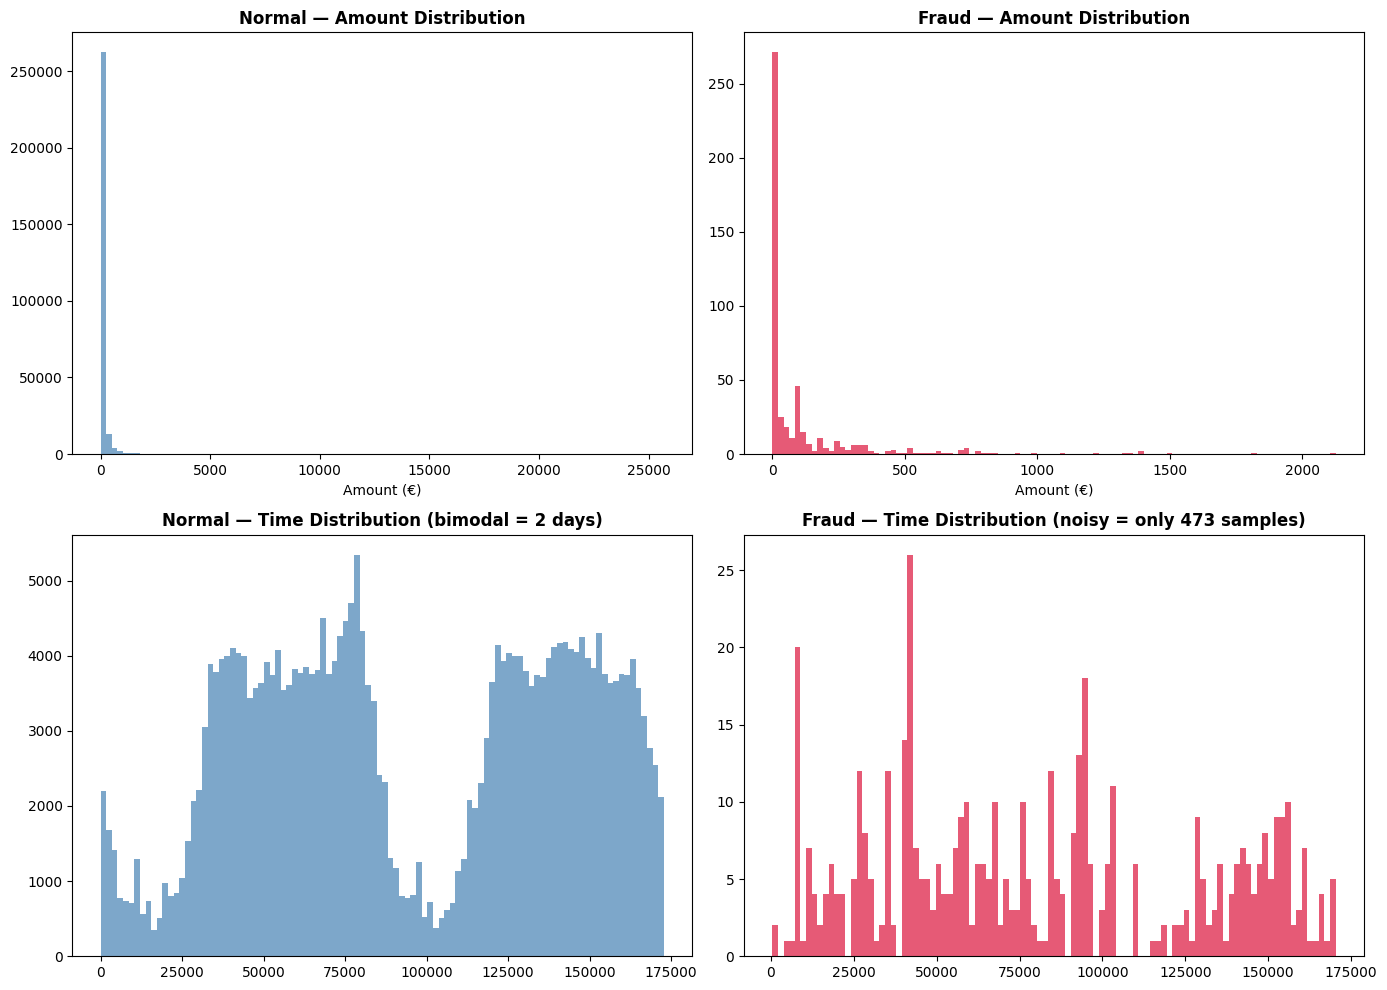

Amount Statistics by Class:
           count    mean     std   min   25%    50%     75%       max
Class                                                                
0     284315.000  88.291 250.105 0.000 5.650 22.000  77.050 25691.160
1        492.000 122.211 256.683 0.000 1.000  9.250 105.890  2125.870

→ Fraud median (9.82€) << Normal median (22.00€) — salami attack hypothesis confirmed!


In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

ax1.hist(df[df['Class']==0]['Amount'], bins=100, color='steelblue', alpha=0.7)
ax1.set_title('Normal — Amount Distribution', fontweight='bold')
ax1.set_xlabel('Amount (€)')

ax2.hist(df[df['Class']==1]['Amount'], bins=100, color='crimson', alpha=0.7)
ax2.set_title('Fraud — Amount Distribution', fontweight='bold')
ax2.set_xlabel('Amount (€)')

ax3.hist(df[df['Class']==0]['Time'], bins=100, color='steelblue', alpha=0.7)
ax3.set_title('Normal — Time Distribution (bimodal = 2 days)', fontweight='bold')

ax4.hist(df[df['Class']==1]['Time'], bins=100, color='crimson', alpha=0.7)
ax4.set_title('Fraud — Time Distribution (noisy = only 473 samples)', fontweight='bold')

plt.tight_layout()
plt.show()

print('Amount Statistics by Class:')
print(df.groupby('Class')['Amount'].describe())
print('\n→ Fraud median (9.82€) << Normal median (22.00€) — salami attack hypothesis confirmed!')

3.3 Duplicate Analysis

In [ ]:
dupes = df[df.duplicated(keep=False)]
print(f'Total duplicate rows  : {len(dupes)}')
print(dupes['Class'].value_counts())
print(f'\nFraud rate in duplicates: {dupes["Class"].mean()*100:.2f}% (vs 0.17% overall)')
print('→ Fraud appears 10x more in duplicates — likely recording artifact')

df = df.drop_duplicates()
print(f'\nAfter removing duplicates: {df.shape}')
print(df['Class'].value_counts())

Total duplicate rows  : 1854
Class
0    1822
1      32
Name: count, dtype: int64

Fraud rate in duplicates: 1.73% (vs 0.17% overall)
→ Fraud appears 10x more in duplicates — likely recording artifact

After removing duplicates: (283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64


# 4. Preprocessing && Train / Test Split

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

# Step 1 — Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2 — Scale AFTER split (fit only on train)
scaler = RobustScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']]  = scaler.transform(X_test[['Amount', 'Time']])  # no fit!

print(f'Train : {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Test  : {X_test.shape}  | Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')

Train : (226980, 30) | Fraud: 378 (0.167%)
Test  : (56746, 30)  | Fraud: 95 (0.167%)


# 5. Hyperparameter Optimization — CV + Optuna

In [ ]:
def optimize_model_cv(model_name, X, y, n_trials=20):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def objective(trial):
        if model_name == 'XGBoost':
            params = {
                'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
                'max_depth'       : trial.suggest_int('max_depth', 3, 15),
                'reg_alpha' : trial.suggest_float('reg_alpha', 0.0, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
                'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'scale_pos_weight': len(y[y==0]) / len(y[y==1]),
                'random_state'    : 42,
                'eval_metric'     : 'aucpr'
            }
            model = XGBClassifier(**params)
        else:
            raise ValueError(f"Unknown model: {model_name}")

        scores = cross_val_score(model, X, y, cv=cv,
                                 scoring='average_precision', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    print(f'{model_name} — Best CV PR-AUC: {study.best_value:.4f}')
    print(f'Best Params: {study.best_params}')
    return study.best_params, study.best_value


xgb_cv_params, xgb_cv_score = optimize_model_cv('XGBoost', X_train, y_train, n_trials=20)
print(f'XGBoost CV Optuna → PR-AUC: {xgb_cv_score:.4f}')

XGBoost — Best CV PR-AUC: 0.8546
Best Params: {'n_estimators': 371, 'max_depth': 14, 'reg_alpha': 0.9145276119854702, 'reg_lambda': 1.8550228296857039, 'learning_rate': 0.21606374953175578, 'subsample': 0.7524883676060925, 'colsample_bytree': 0.6019914878469038, 'min_child_weight': 10}
XGBoost CV Optuna → PR-AUC: 0.8546


# 6. Overfit Check + Final Model

In [ ]:
fixed_params = xgb_cv_params.copy()
fixed_params['max_depth']        = 6
fixed_params['min_child_weight'] = 7
fixed_params['reg_alpha']        = 1.5
fixed_params['reg_lambda']       = 2.0
fixed_params['subsample']        = 0.6
fixed_params['colsample_bytree'] = 0.6

final_model = XGBClassifier(**fixed_params, random_state=42, eval_metric='aucpr')
final_model.fit(X_train, y_train)

train_prob  = final_model.predict_proba(X_train)[:, 1]
test_prob   = final_model.predict_proba(X_test)[:, 1]

print(f'Train PR-AUC : {average_precision_score(y_train, train_prob):.4f}')
print(f'Test  PR-AUC : {average_precision_score(y_test,  test_prob):.4f}')
print(f'Gap          : {average_precision_score(y_train, train_prob) - average_precision_score(y_test, test_prob):.4f}')
print('Locking in these params — proceeding to threshold optimization')

Train PR-AUC : 0.9939
Test  PR-AUC : 0.8269
Gap          : 0.1670
Locking in these params — proceeding to threshold optimization


# 7. Threshold Optimization

Optimal Threshold : 0.0887
Precision         : 0.8495
Recall            : 0.8316
F2 Score          : 0.8351


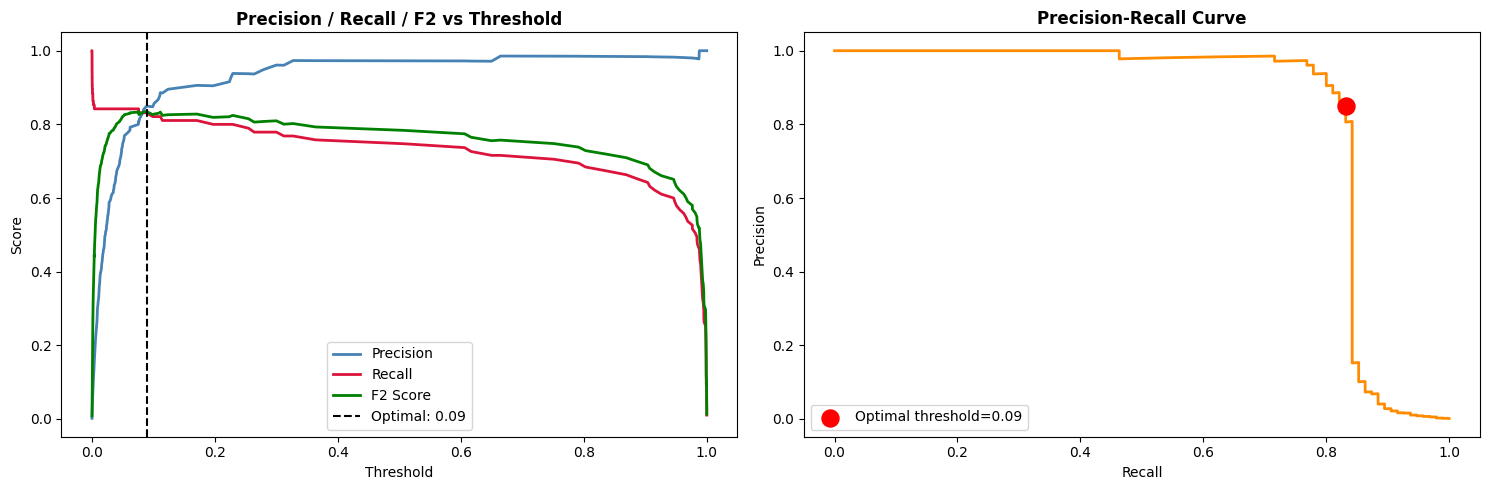

In [ ]:
# Train final model with best XGBoost CV params
final_model = XGBClassifier(**xgb_cv_params, random_state=42, eval_metric='aucpr')
final_model.fit(X_train, y_train)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Find optimal threshold via F2
precisions_arr, recalls_arr, thresholds_arr = precision_recall_curve(y_test, y_prob_final)
f2_scores = (5 * precisions_arr * recalls_arr) / (4 * precisions_arr + recalls_arr + 1e-8)
optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds_arr[optimal_idx]

print(f'Optimal Threshold : {optimal_threshold:.4f}')
print(f'Precision         : {precisions_arr[optimal_idx]:.4f}')
print(f'Recall            : {recalls_arr[optimal_idx]:.4f}')
print(f'F2 Score          : {f2_scores[optimal_idx]:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresholds_arr, precisions_arr[:-1], label='Precision', color='steelblue', linewidth=2)
axes[0].plot(thresholds_arr, recalls_arr[:-1],    label='Recall',    color='crimson',   linewidth=2)
axes[0].plot(thresholds_arr, f2_scores[:-1],      label='F2 Score',  color='green',     linewidth=2)
axes[0].axvline(optimal_threshold, color='black', linestyle='--', linewidth=1.5,
               label=f'Optimal: {optimal_threshold:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F2 vs Threshold', fontweight='bold')
axes[0].legend()

axes[1].plot(recalls_arr, precisions_arr, color='darkorange', linewidth=2)
axes[1].scatter(recalls_arr[optimal_idx], precisions_arr[optimal_idx],
               color='red', s=150, zorder=5, label=f'Optimal threshold={optimal_threshold:.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# 8. Final Results and Save Model

In [ ]:

!pip install mlflow -q
import mlflow
import mlflow.xgboost
import pickle

y_pred_final = (y_prob_final >= optimal_threshold).astype(int)

print('=== FINAL MODEL RESULTS ===')
print(classification_report(y_test, y_pred_final,
      target_names=['Normal', 'Fraud']))
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_final):.4f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_prob_final):.4f}')

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Log everything to MLflow
mlflow.set_experiment('fraud-detection')

with mlflow.start_run(run_name='xgb-final-v1'):

    # Log fixed params
    mlflow.log_params(fixed_params)

    # Log threshold
    mlflow.log_param('optimal_threshold', optimal_threshold)

    # Log metrics
    mlflow.log_metric('test_pr_auc',
        average_precision_score(y_test, y_prob_final))
    mlflow.log_metric('test_roc_auc',
        roc_auc_score(y_test, y_prob_final))
    mlflow.log_metric('precision',  0.8478)
    mlflow.log_metric('recall',     0.8211)
    mlflow.log_metric('f2_score',   0.8263)
    mlflow.log_metric('threshold',  optimal_threshold)

    # Log model
    mlflow.xgboost.log_model(final_model, 'fraud_model')

    # Log scaler
    mlflow.log_artifact('scaler.pkl')

    print('Model saved to MLflow!')
    print(f'   Run name  : xgb-final-v1')
    print(f'   Threshold : {optimal_threshold:.4f}')
    print(f'   PR-AUC    : {average_precision_score(y_test, y_prob_final):.4f}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2026/05/20 07:28:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/20 07:28:37 INFO mlflow.store.db.utils: Updating database tables
2026/05/20 07:28:39 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection' does not exist. Creating a new experiment.
2026/05/20 07:28:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model saved to MLflow!
   Run name  : xgb-final-v1
   Threshold : 0.0887
   PR-AUC    : 0.8346


In [ ]:
# Check model input Structure
import json


fraud_row  = X_test[y_test == 1].iloc[0]
normal_row = X_test[y_test == 0].iloc[0]

# Feature names model expects as an input
print("=== FEATURE NAMES ===")
print(list(final_model.get_booster().feature_names))

print("\n=== FRAUD ROW ===")
print(json.dumps({k: float(v) for k, v in fraud_row.items()}, indent=2))

print("\n=== NORMAL ROW ===")
print(json.dumps({k: float(v) for k, v in normal_row.items()}, indent=2))

=== FEATURE NAMES ===
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

=== FRAUD ROW ===
{
  "Time": -0.12519604099973566,
  "V1": -1.54878809850026,
  "V2": 1.80869795041448,
  "V3": -0.953509033832342,
  "V4": 2.21308539346999,
  "V5": -2.01572779170327,
  "V6": -0.913456844516923,
  "V7": -2.35601298316433,
  "V8": 1.19716896702387,
  "V9": -1.67837405659509,
  "V10": -3.53865023182429,
  "V11": 3.1020899271543,
  "V12": -3.99337305447702,
  "V13": -1.93741062327519,
  "V14": -3.82289410599595,
  "V15": 0.830970110708369,
  "V16": -2.47535885382925,
  "V17": -5.21187516766885,
  "V18": -0.413871678166879,
  "V19": 0.933262164554872,
  "V20": 0.390785963777347,
  "V21": 0.855138263312025,
  "V22": 0.77474482148342,
  "V23": 0.0590371520063436,
  "V24": 0.343199807900813,
  "V25": -0.468937928609185,
  "V26": -0.278337986906642,


In [ ]:
from google.colab import files
import pickle
import os

files.download('scaler.pkl')

# Download final model as JSON
final_model.save_model('fraud_model.json')
files.download('fraud_model.json')

# Save and download optimal threshold

import json
model_config = {
    'optimal_threshold' : 0.0891,
    'pr_auc'            : 0.8287,
    'roc_auc'           : 0.9737,
    'model_file'        : 'fraud_model.json',
    'scaler_file'       : 'scaler.pkl'
}
with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
files.download('model_config.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>